Визуализация данных о действиях пользователей маркетплейса от Т-банк.

In [10]:
import pandas as pd
import numpy as np
import glob
import os

Считываю данные

In [11]:
!pip3 install fastparquet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

users_df = pd.read_parquet('/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/users.pq')
retail_items_df = pd.read_parquet('/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/retail/items.pq', engine='fastparquet')
marketplace_items_df = pd.read_parquet('/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/marketplace/items.pq', engine='fastparquet')
brands_df = pd.read_parquet('/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/brands.pq', engine='fastparquet') #fastparquet из-за столбца с массивами данных

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
users_df.head(10)
print("Размер ДФ клиентов:", users_df.shape)
#print("Размер ДФ товаров из папки retail:", items_retail.shape)
#print("Размер ДФ товаров из папки marketplace:", items_marketplace.shape)

При попытке считывания файла items в таблицу, процесс обрывается, так как кончается оперативная память. Вес файла 2,5 гб. Поэтому продолжаю работу в IDE PyCharm.

In [ ]:
!du -h /content/drive/MyDrive/T-ECD-dataset/small/dataset/small/marketplace/items.pq
!du -h /content/drive/MyDrive/T-ECD-dataset/small/dataset/small/retail/items.pq



#Получил:
Размер ДФ клиентов: (3500000, 3)

Размер ДФ товаров из папки retail: (250171, 6)

Размер ДФ товаров из папки marketplace: (2325409, 6)

#Считываю действия за последние 30 дней
Из-за большого объема данных сложно взять больше, учебная цель - продолжать работать с библиотекой pandas.

In [ ]:
events_marketplace_path = '/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/marketplace/events'
all_marketplace_events = sorted(glob.glob(os.path.join(events_marketplace_path, "*.pq"))) #нахожу все файлы формата паркет в папке действий (events) из папки marketplace и сортирую по порядку

#Берем последние 30 файлов (дней) из папки marketplace
recent_files = all_marketplace_events[-30:]

events_list = []
for file in recent_files:
    df_temp = pd.read_parquet(file, engine='fastparquet')
    day = os.path.basename(file).replace('.pq', '')
    df_temp['day'] = day #добавляю столбец day в датафрейм, чтоб отследить к какому дню относится действие в общей таблице
    events_list.append(df_temp)

marketplace_events_df = pd.concat(events_list, ignore_index=True)
print(f"Итоговый размер: {marketplace_events_df.shape}")
print(marketplace_events_df.columns)

#считываем все файлы паркет из папки действий в папке retail
events_retail_path = '/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/retail/events'
all_retail_events= sorted(glob.glob(os.path.join(events_retail_path, "*.pq"))) #нахожу все файлы формата паркет в папке действий (events) из папки marketplace и сортирую по порядку

#Берем последние 30 файлов (дней) из папки retail
recent_files = all_retail_events[-30:]

print(f"Берём данные за {len(recent_files)} дней из папки retail:")
events_list = []
for file in recent_files:
    df_temp = pd.read_parquet(file, engine='fastparquet')
    day = os.path.basename(file).replace('.pq', '')
    df_temp['day'] = day
    events_list.append(df_temp)

retail_events_df = pd.concat(events_list, ignore_index=True)
print(f"Итоговый размер: {retail_events_df.shape}")
print(retail_events_df.columns)

#Вывод программы

Берём данные за 30 дней из папки marketplace:

Итоговый размер: (17790404, 7)

Index(['timestamp', 'user_id', 'item_id', 'subdomain', 'action_type', 'os',
       'day'],
      dtype='object')

Берём данные за 30 дней из папки retail:

Итоговый размер: (47376689, 7)

Index(['timestamp', 'user_id', 'item_id', 'subdomain', 'action_type', 'os',
       'day'],
      dtype='object')

#Построю столбчатые диаграммы распределения основных действий пользователей в marketplace и retail

In [ ]:
import matplotlib.pyplot as plt #импортирую библиотеку для работы с графиками

#построение первого графика для marketplace
plt.figure(figsize=(12, 6))
action_counts = marketplace_events_df['action_type'].value_counts()
action_counts.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.8)

plt.title('Распределение типов действий пользователей marketplace', fontsize=16, fontweight='bold')
plt.xlabel('Тип действия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Наклон подписей по оси X для читаемости
plt.grid(axis='y', alpha=0.3)

#подписи значений на столбцах
for i, count in enumerate(action_counts):
    plt.text(i, count + max(action_counts)*0.01, str(count),
             ha='center', va='bottom', fontsize=10)

#показываю график (у себя в IDE сохраняю в папку plots проекта)
plt.tight_layout()
plt.show()

#построение второго графика для retail
plt.figure(figsize=(12, 6))
retail_actions = retail_events_df['action_type'].value_counts()
print(type(retail_actions))
retail_actions.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.8)

plt.title('Распределение типов действий пользователей retail', fontsize=16, fontweight='bold')
plt.xlabel('Тип действия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for i, count in enumerate(retail_actions):
    plt.text(i, count + max(retail_actions)*0.01, str(count),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Из-за большого объема данных и нехватки ОЗУ в collab, прикрепляю график изображением.
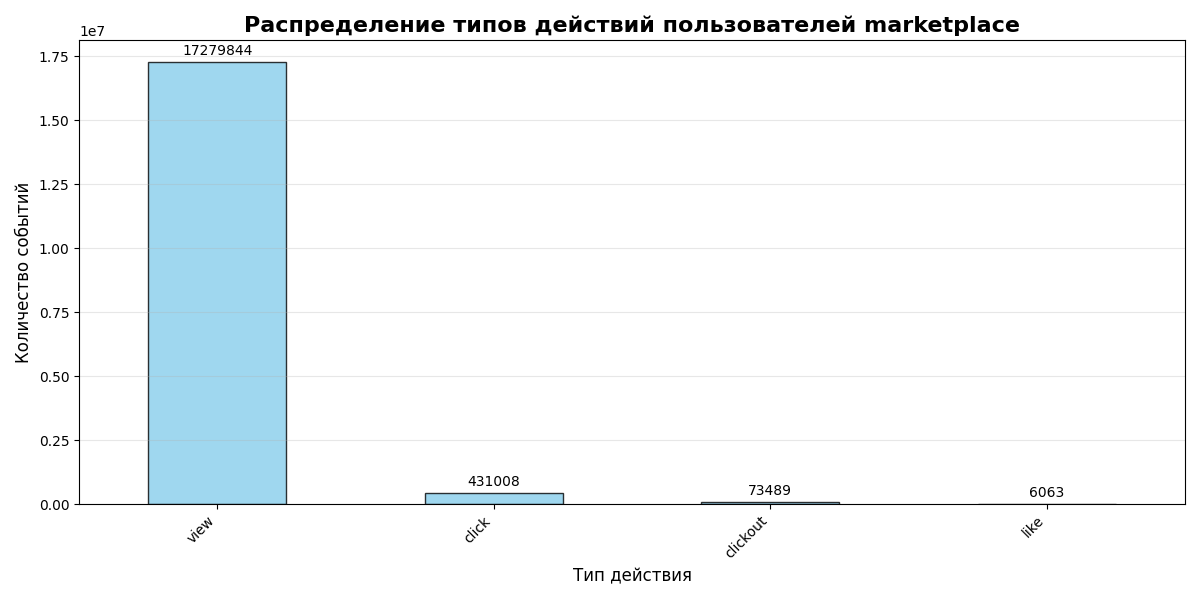


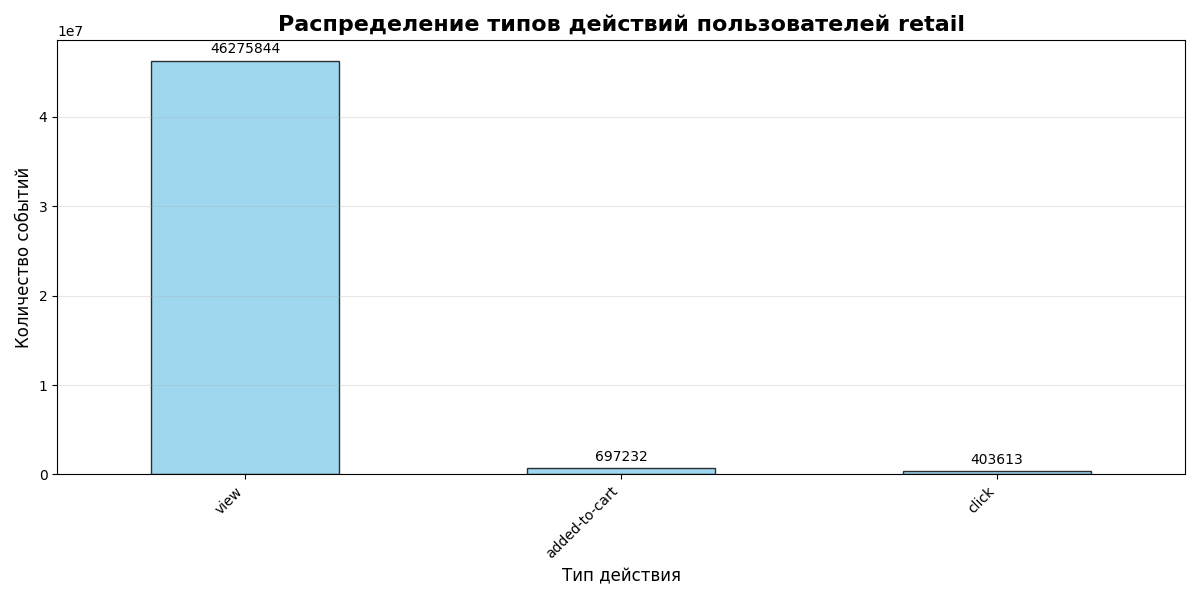

#Построю столбчатые диаграммы распределения основных действий пользователей в разных subdomain из папок marketplace и retail

In [ ]:
#Построю диаграмму распределения действий в разных subdomain из папки marketplace: в поиске, каталоге, на главной странице, в рекомендациях (u2i, i2i)
plt.figure(figsize=(12, 6))
marketplace_subdomains = marketplace_events_df['subdomain'].value_counts()
marketplace_subdomains.plot(kind='bar', color='yellow', edgecolor='black', alpha=0.8)
plt.title('Распределение действий пользователей в subdomains из marketplace', fontsize=16, fontweight='bold')
plt.xlabel('Subdomain', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(marketplace_subdomains):
    plt.text(i, count + max(marketplace_subdomains)*0.01, str(count),
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

#Построю диаграмму распределения действий в разных subdomain: поиск, каталог, страницы товаров и корзина
plt.figure(figsize=(12, 6))
retail_subdomains = retail_events_df['subdomain'].value_counts()
retail_subdomains.plot(kind='bar', color='yellow', edgecolor='black', alpha=0.8)
plt.title('Распределение действий пользователей в subdomains из retail', fontsize=16, fontweight='bold')
plt.xlabel('Subdomain', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(retail_subdomains):
    plt.text(i, count + max(retail_subdomains)*0.01, str(count),
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

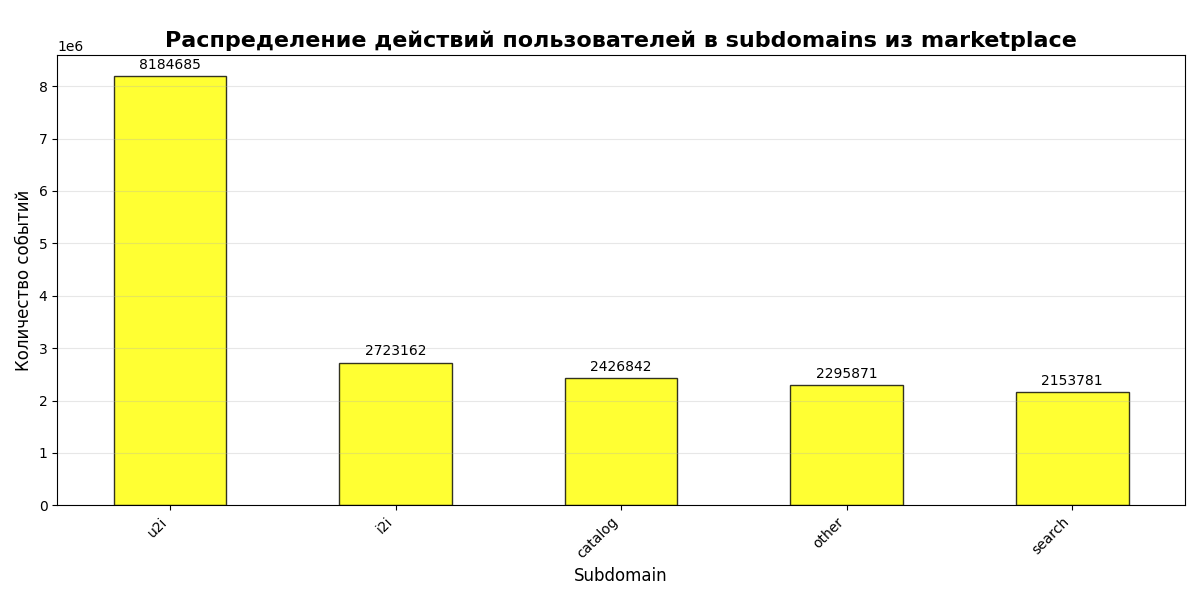

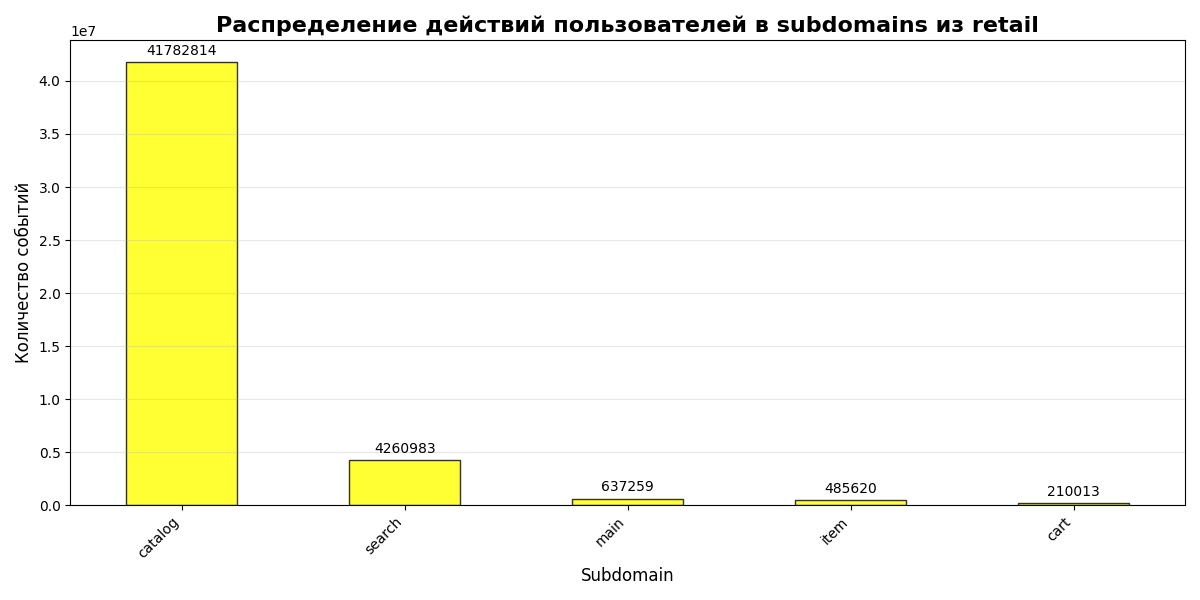

#Построю столбчатые диаграммы распределения основных действий пользователей в marketplace и retail по операционным системам

In [ ]:
#Построю диаграмму распределения действий в разных OS из папки marketplace
plt.figure(figsize=(12, 6))
marketplace_os = marketplace_events_df['os'].value_counts()
marketplace_os.plot(kind='bar', color='green', edgecolor='black', alpha=0.8)
plt.title('Распределение действий пользователей по OS из marketplace', fontsize=16, fontweight='bold')
plt.xlabel('OS', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(marketplace_os):
    plt.text(i, count + max(marketplace_os)*0.01, str(count),
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

#Построю диаграмму распределения действий в разных OS из папки retail
plt.figure(figsize=(12, 6))
retail_os = retail_events_df['os'].value_counts()
retail_os.plot(kind='bar', color='green', edgecolor='black', alpha=0.8)
plt.title('Распределение действий пользователей по OS из retail', fontsize=16, fontweight='bold')
plt.xlabel('OS', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(retail_os):
    plt.text(i, count + max(retail_os)*0.01, str(count),
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

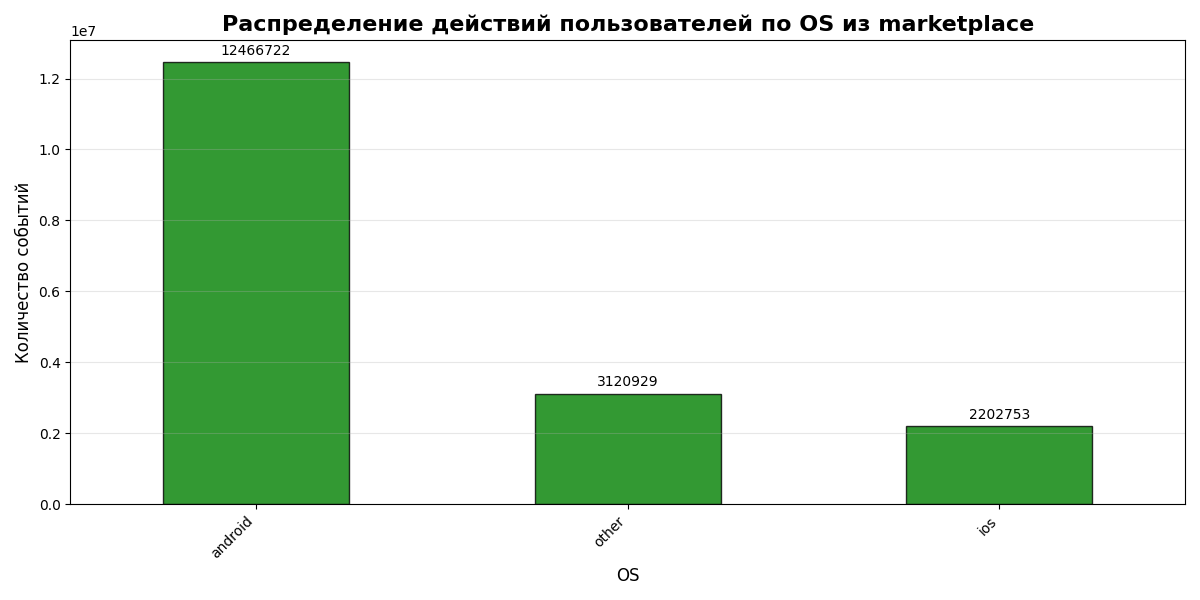

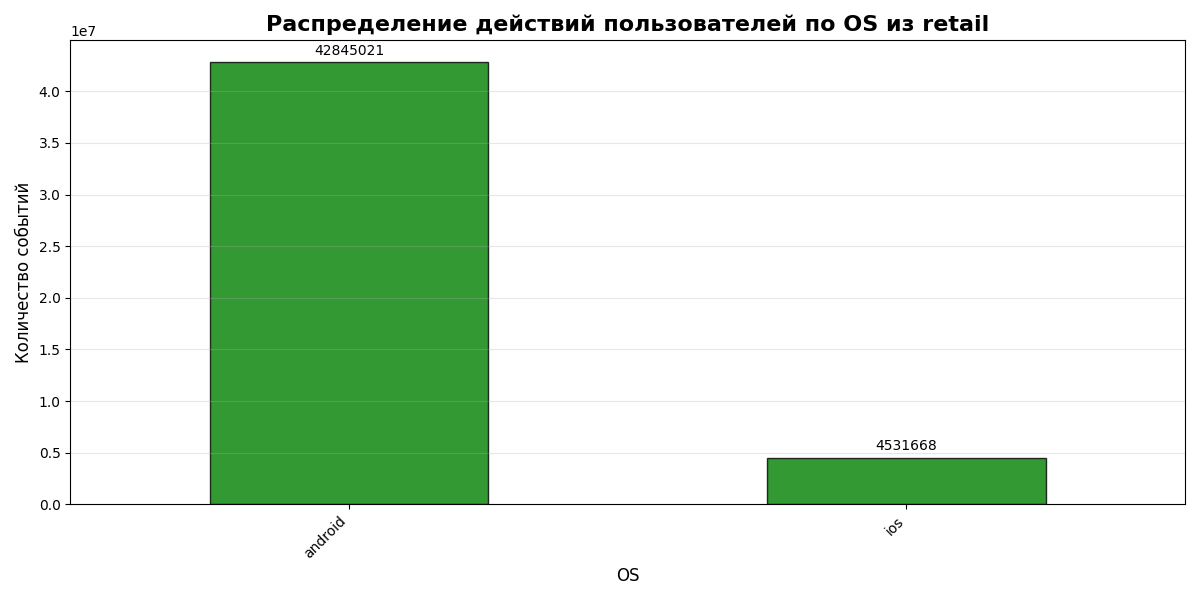

#Построю heatmap по стобцам action_type и subdomain из двух папок. Попробуем посмотреть, в каких плейсментах сайтов выше конверсия в целевое действие.

In [2]:
import seaborn as sns

In [ ]:
#построю тепловую карту Действие - Место в marketplace
plt.figure(figsize=(12, 6))
action_subdomain_market = pd.crosstab(marketplace_events_df['action_type'], marketplace_events_df['subdomain'])
sns.heatmap(action_subdomain_market, fmt='d', cmap='Reds', annot=True)
plt.title('Тепловая карта Действие - Место в marketplace')
plt.tight_layout()
plt.show()

#построю тепловую карту Действие - Место в retail
plt.figure(figsize=(12, 6))
action_subdomain_retail = pd.crosstab(retail_events_df['action_type'], retail_events_df['subdomain'])
sns.heatmap(action_subdomain_retail, fmt='d', cmap='Reds', annot=True)
plt.title('Тепловая карта Действие - Место в retail')
plt.tight_layout()
plt.show()

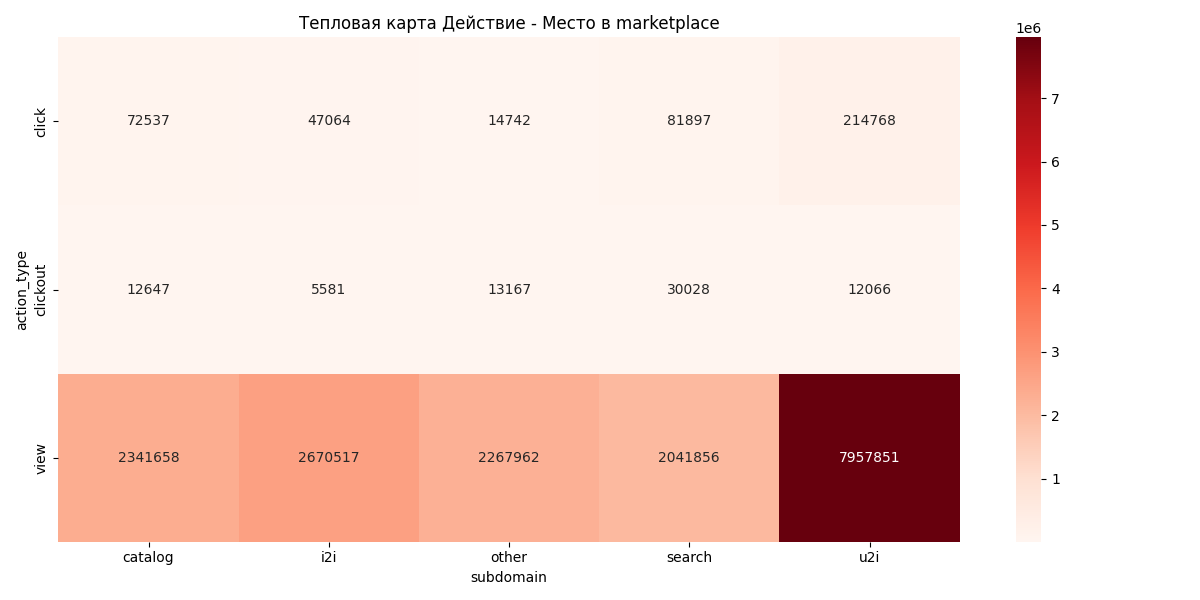

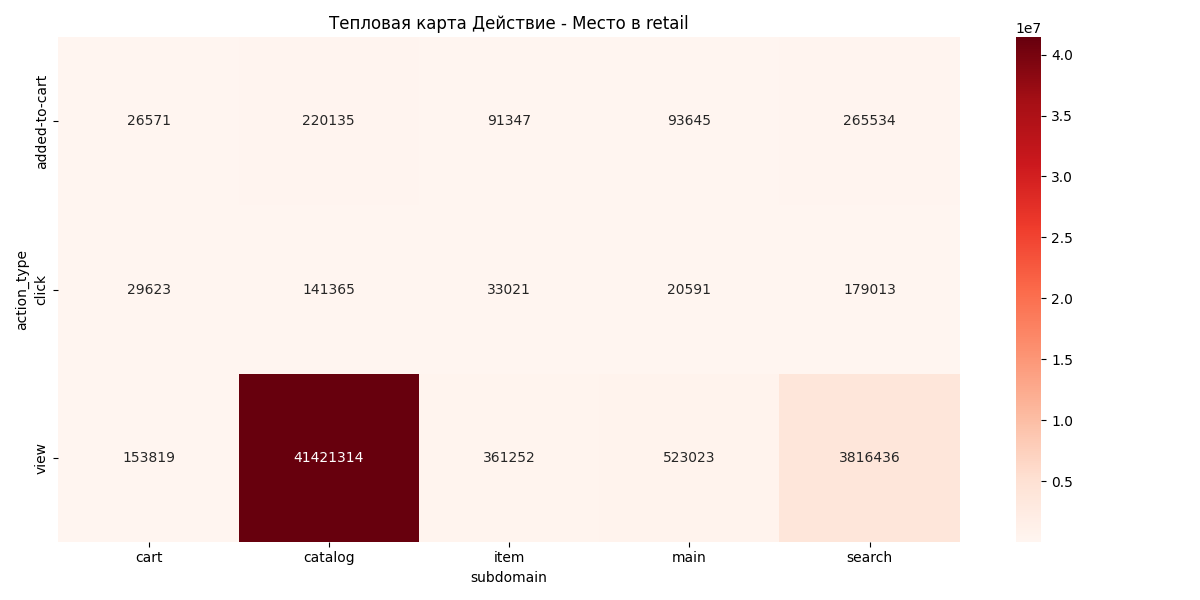

Наиболее важное для нас целевое действие в marketplace - это clickout, в retail - это добавление в корзину (added-to-cart). По тепловой карте видно, что наибольшее взаимодействие пользователя с marketplace было в разделе рекомендаций u2i, а в retail в каталоге, но целевое действие совершалось в других разделах: **в marketplace люди чаще покупали, когда сами искали товар через поиск. А в retail чаще добавляли товар в корзину также, если сами его искали.**

#Сравним конверсию в целевое действие в marketplace и retail


In [ ]:
#конверсия в целевое действие в маркетплейс и в ритейл
clickout = action_counts['clickout'] #беру количество действий кликаут
all_marketplace_events = marketplace_events_df.shape[0] #и все действия маркетплейс
add_to_cart = retail_actions['added-to-cart'] #количество добавлений в корзину
all_retail_events = retail_events_df.shape[0] #и все действия ритейл
conversion = pd.Series([round(clickout/all_marketplace_events * 100, 3), round(add_to_cart/all_retail_events * 100, 3)], index=['marketplace', 'retail'])
#преоброзуем список в одномерный массив пандас, состоящий из конверсий, округленных до тысячных
plt.figure(figsize=(12, 6))
conversion.plot(kind='bar', color='red', edgecolor='black', alpha=0.8)
plt.title('Сравнение конверсии в целевое действие в marketplace и retail', fontsize=16, fontweight='bold')
plt.xlabel('Конверсия', fontsize=12)
plt.ylabel('Проценты', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(conversion):
    plt.text(i, count + max(conversion)*0.01, str(count),
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

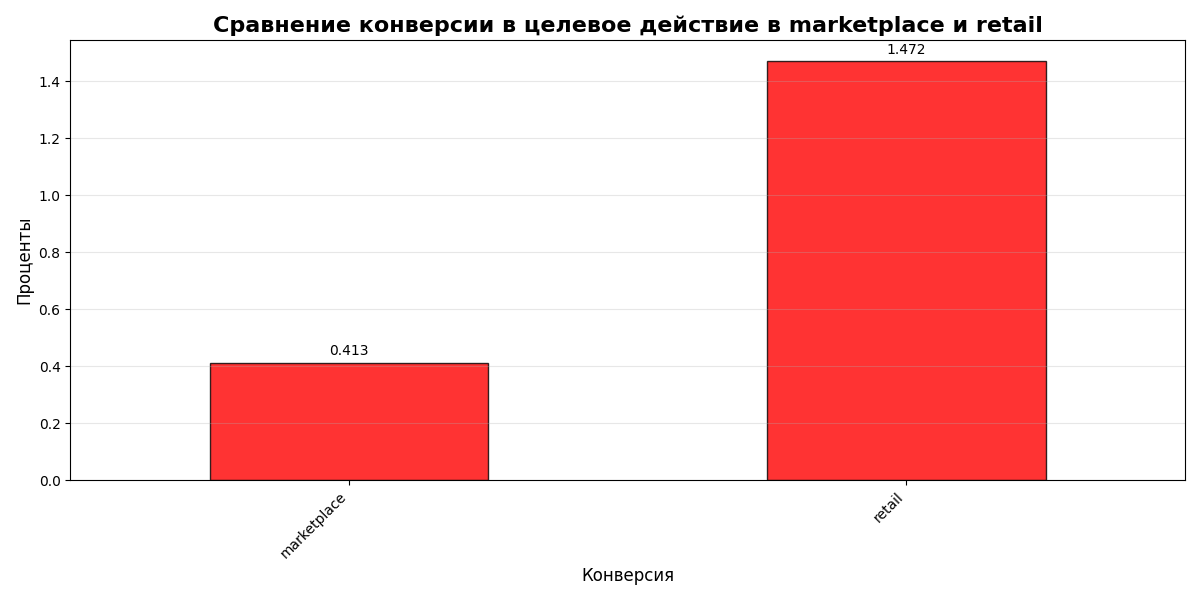

#Построим линейные графики динамики всех действий за период (последний месяц)

In [ ]:
#Маркетплейс
marker_action_dynamics = pd.crosstab(marketplace_events_df['day'], marketplace_events_df['action_type'])
plt.figure(figsize=(16, 10))

for action in marker_action_dynamics.columns:
    plt.plot(marker_action_dynamics.index, marker_action_dynamics[action],
             marker='o', linewidth=2, markersize=4, label=action)
plt.ticklabel_format(style='plain', axis='y') #отключаю научное преобразование чисел
plt.title('Динамика количества действий по типам и дням marketplace', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День', fontsize=12)
plt.ylabel('Количество действий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#ритейл
retail_action_dynamics = pd.crosstab(retail_events_df['day'], retail_events_df['action_type'])
plt.figure(figsize=(16, 10))

for action in retail_action_dynamics.columns:
    plt.plot(retail_action_dynamics.index, retail_action_dynamics[action],
             marker='o', linewidth=2, markersize=4, label=action)
plt.ticklabel_format(style='plain', axis='y') #отключаю научное преобразование чисел
plt.title('Динамика количества действий по типам и дням retail', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День', fontsize=12)
plt.ylabel('Количество действий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

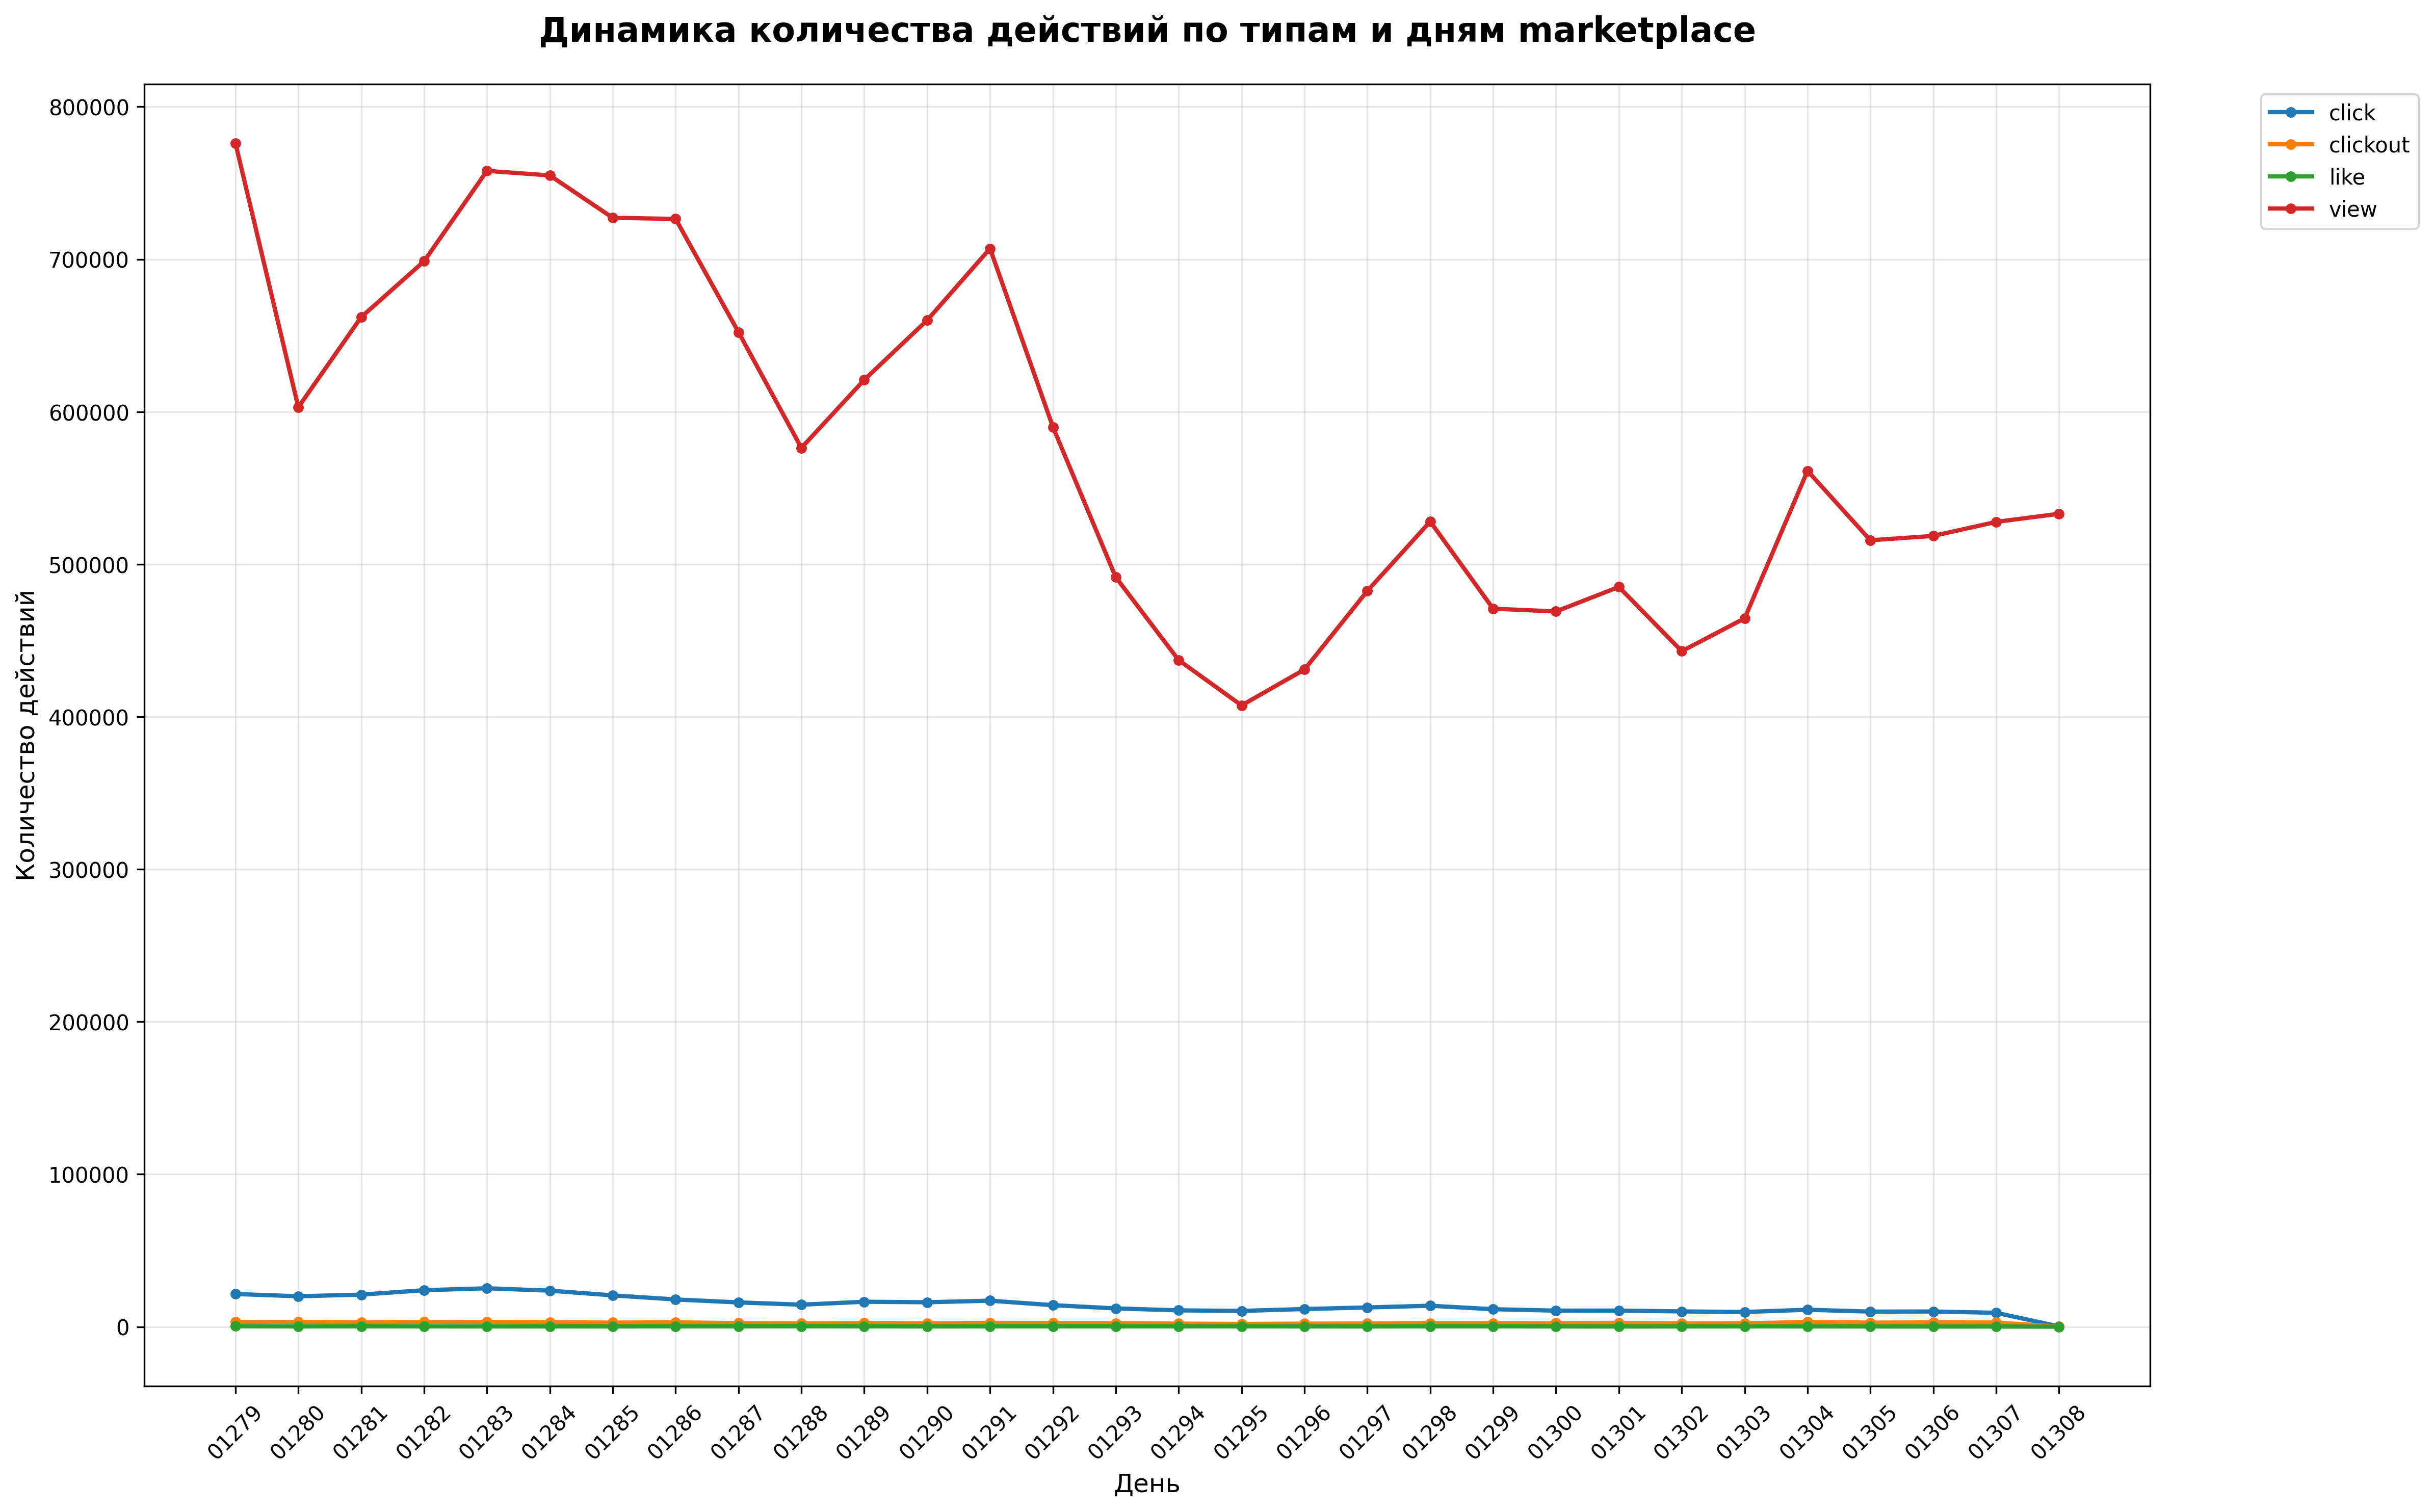

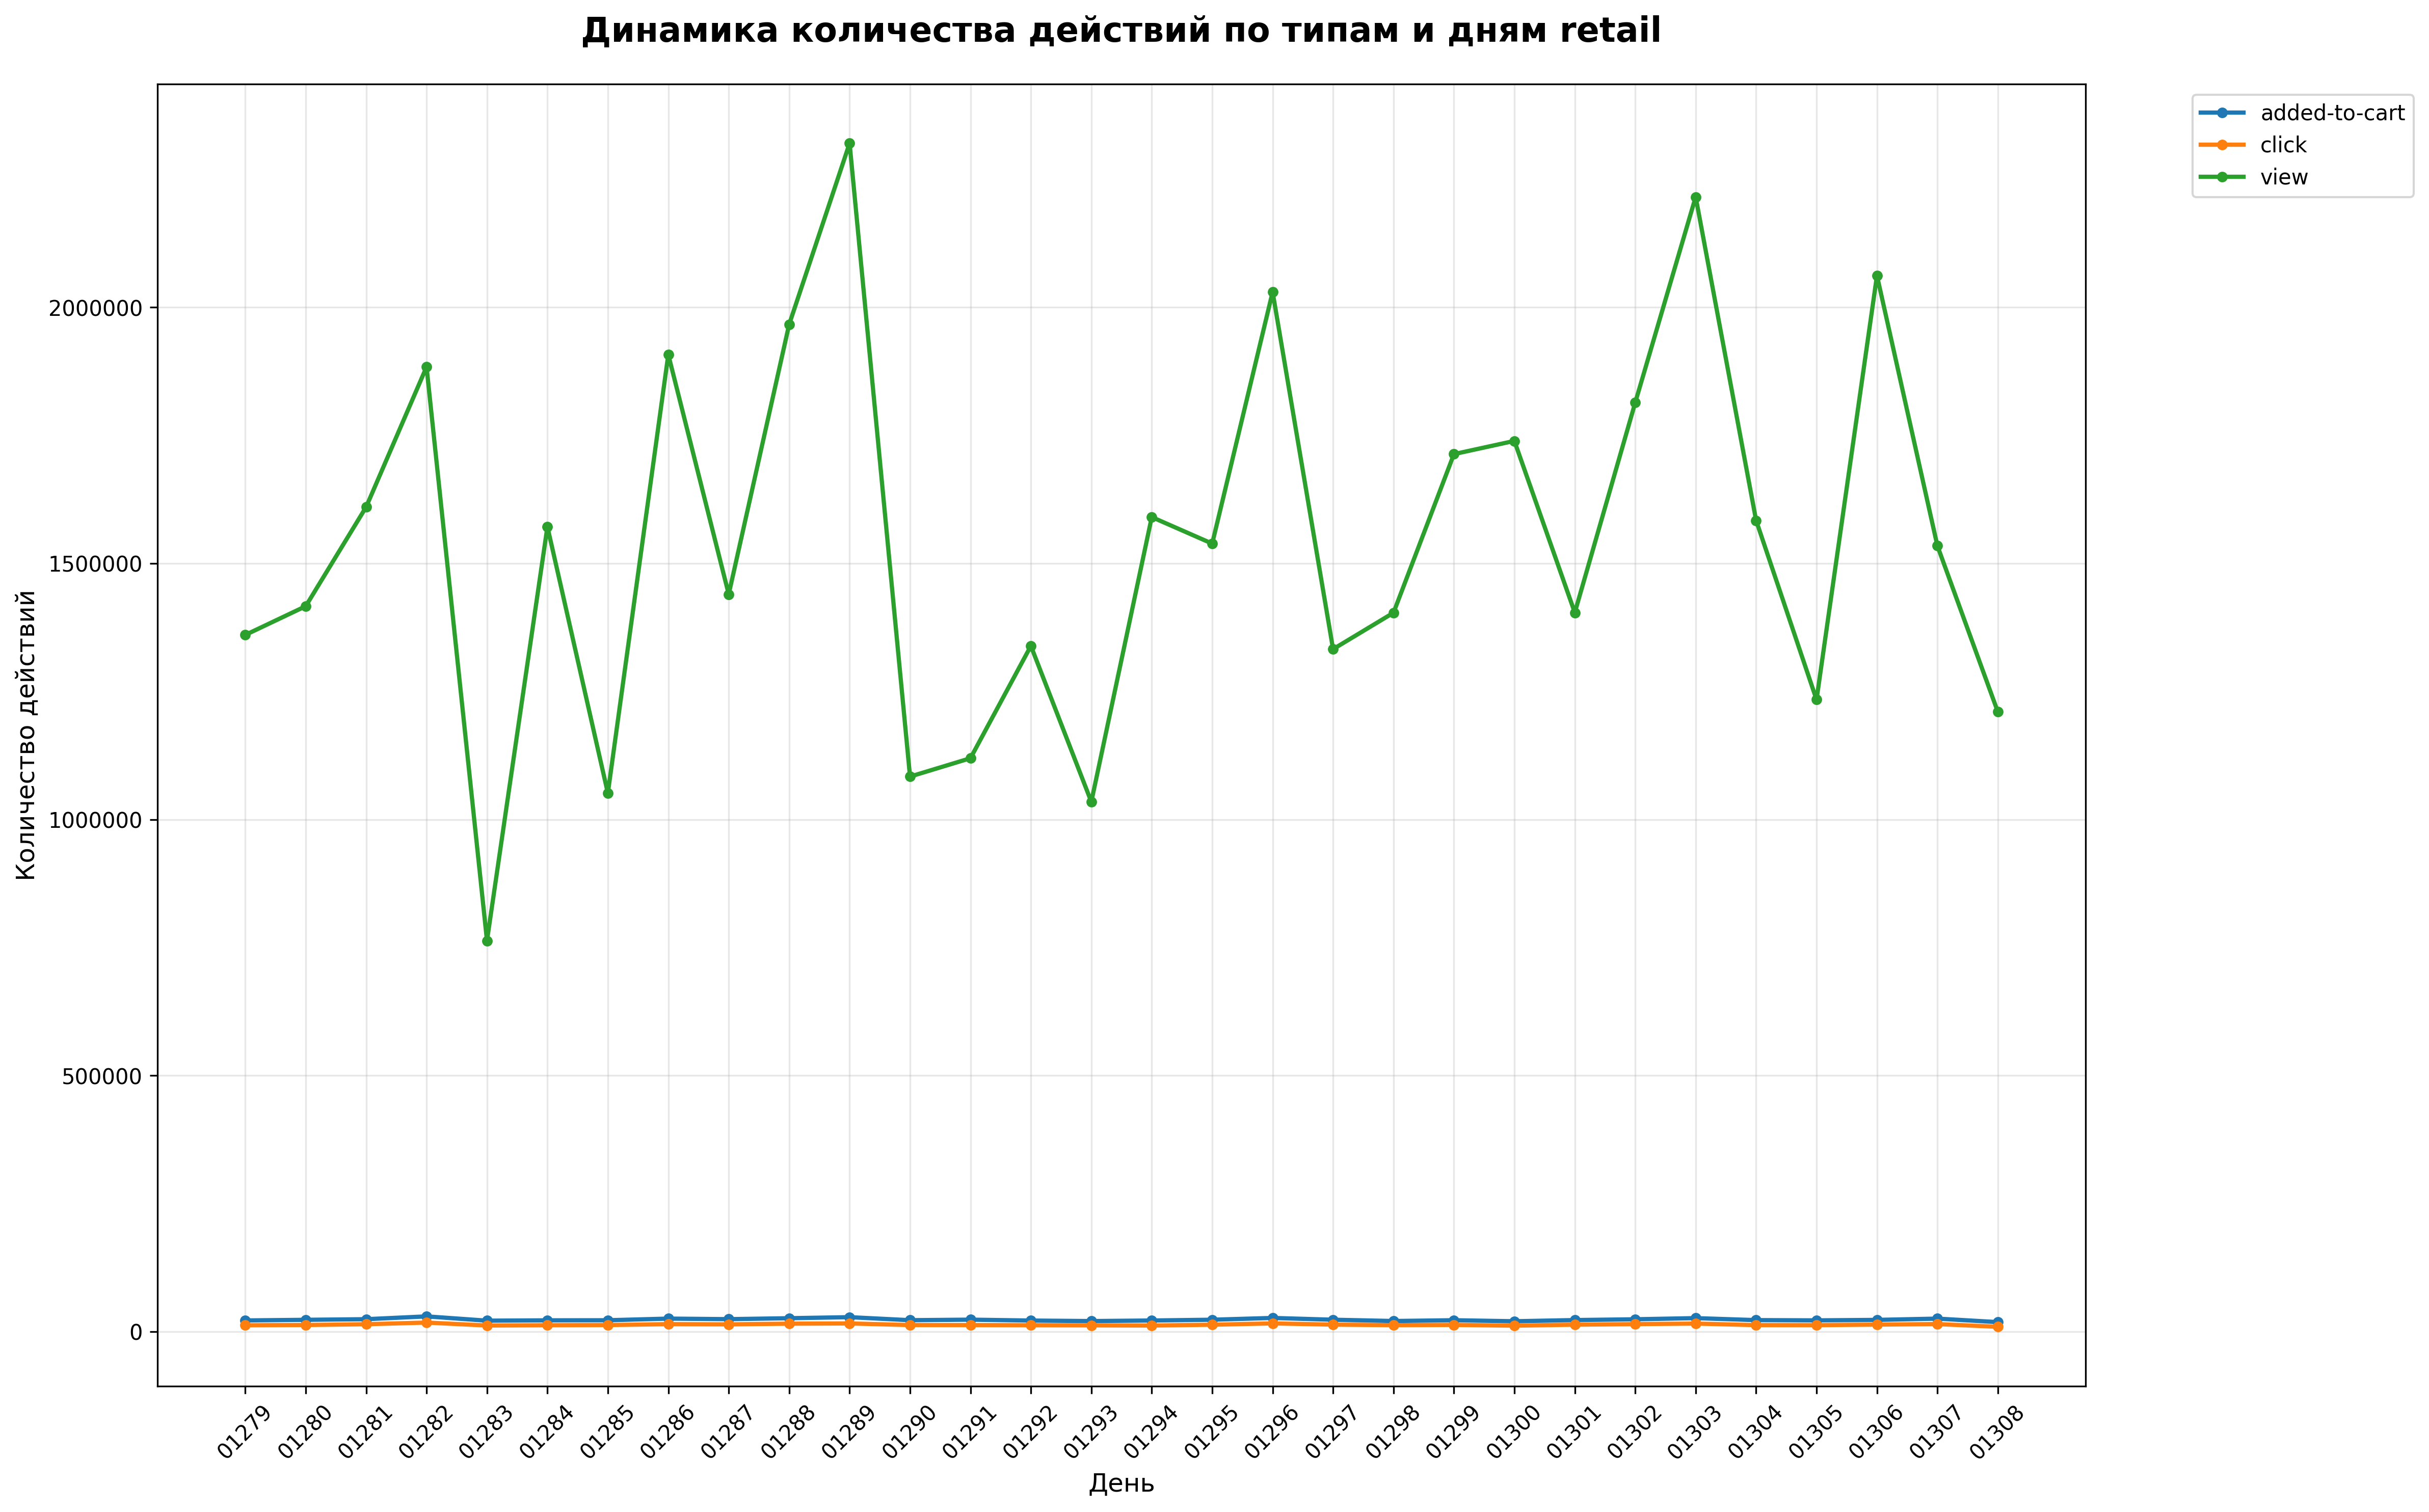

#Так как ключевых действий сильно меньше и плохо видно динамику, построим такой же график только для них и рассмотрим отдельно

In [ ]:
#Построим линейный график изменения действий со временем без действия view
marker_action_dynamics = pd.crosstab(marketplace_events_df['day'], marketplace_events_df['action_type'])
plt.figure(figsize=(16, 10))
market_events_without_view = marker_action_dynamics.iloc[:, :3]
print(market_events_without_view.head())

for action in market_events_without_view.columns:
    plt.plot(market_events_without_view.index, market_events_without_view[action],
             marker='o', linewidth=2, markersize=4, label=action)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Динамика количества действий по типам и дням marketplace', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День', fontsize=12)
plt.ylabel('Количество действий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

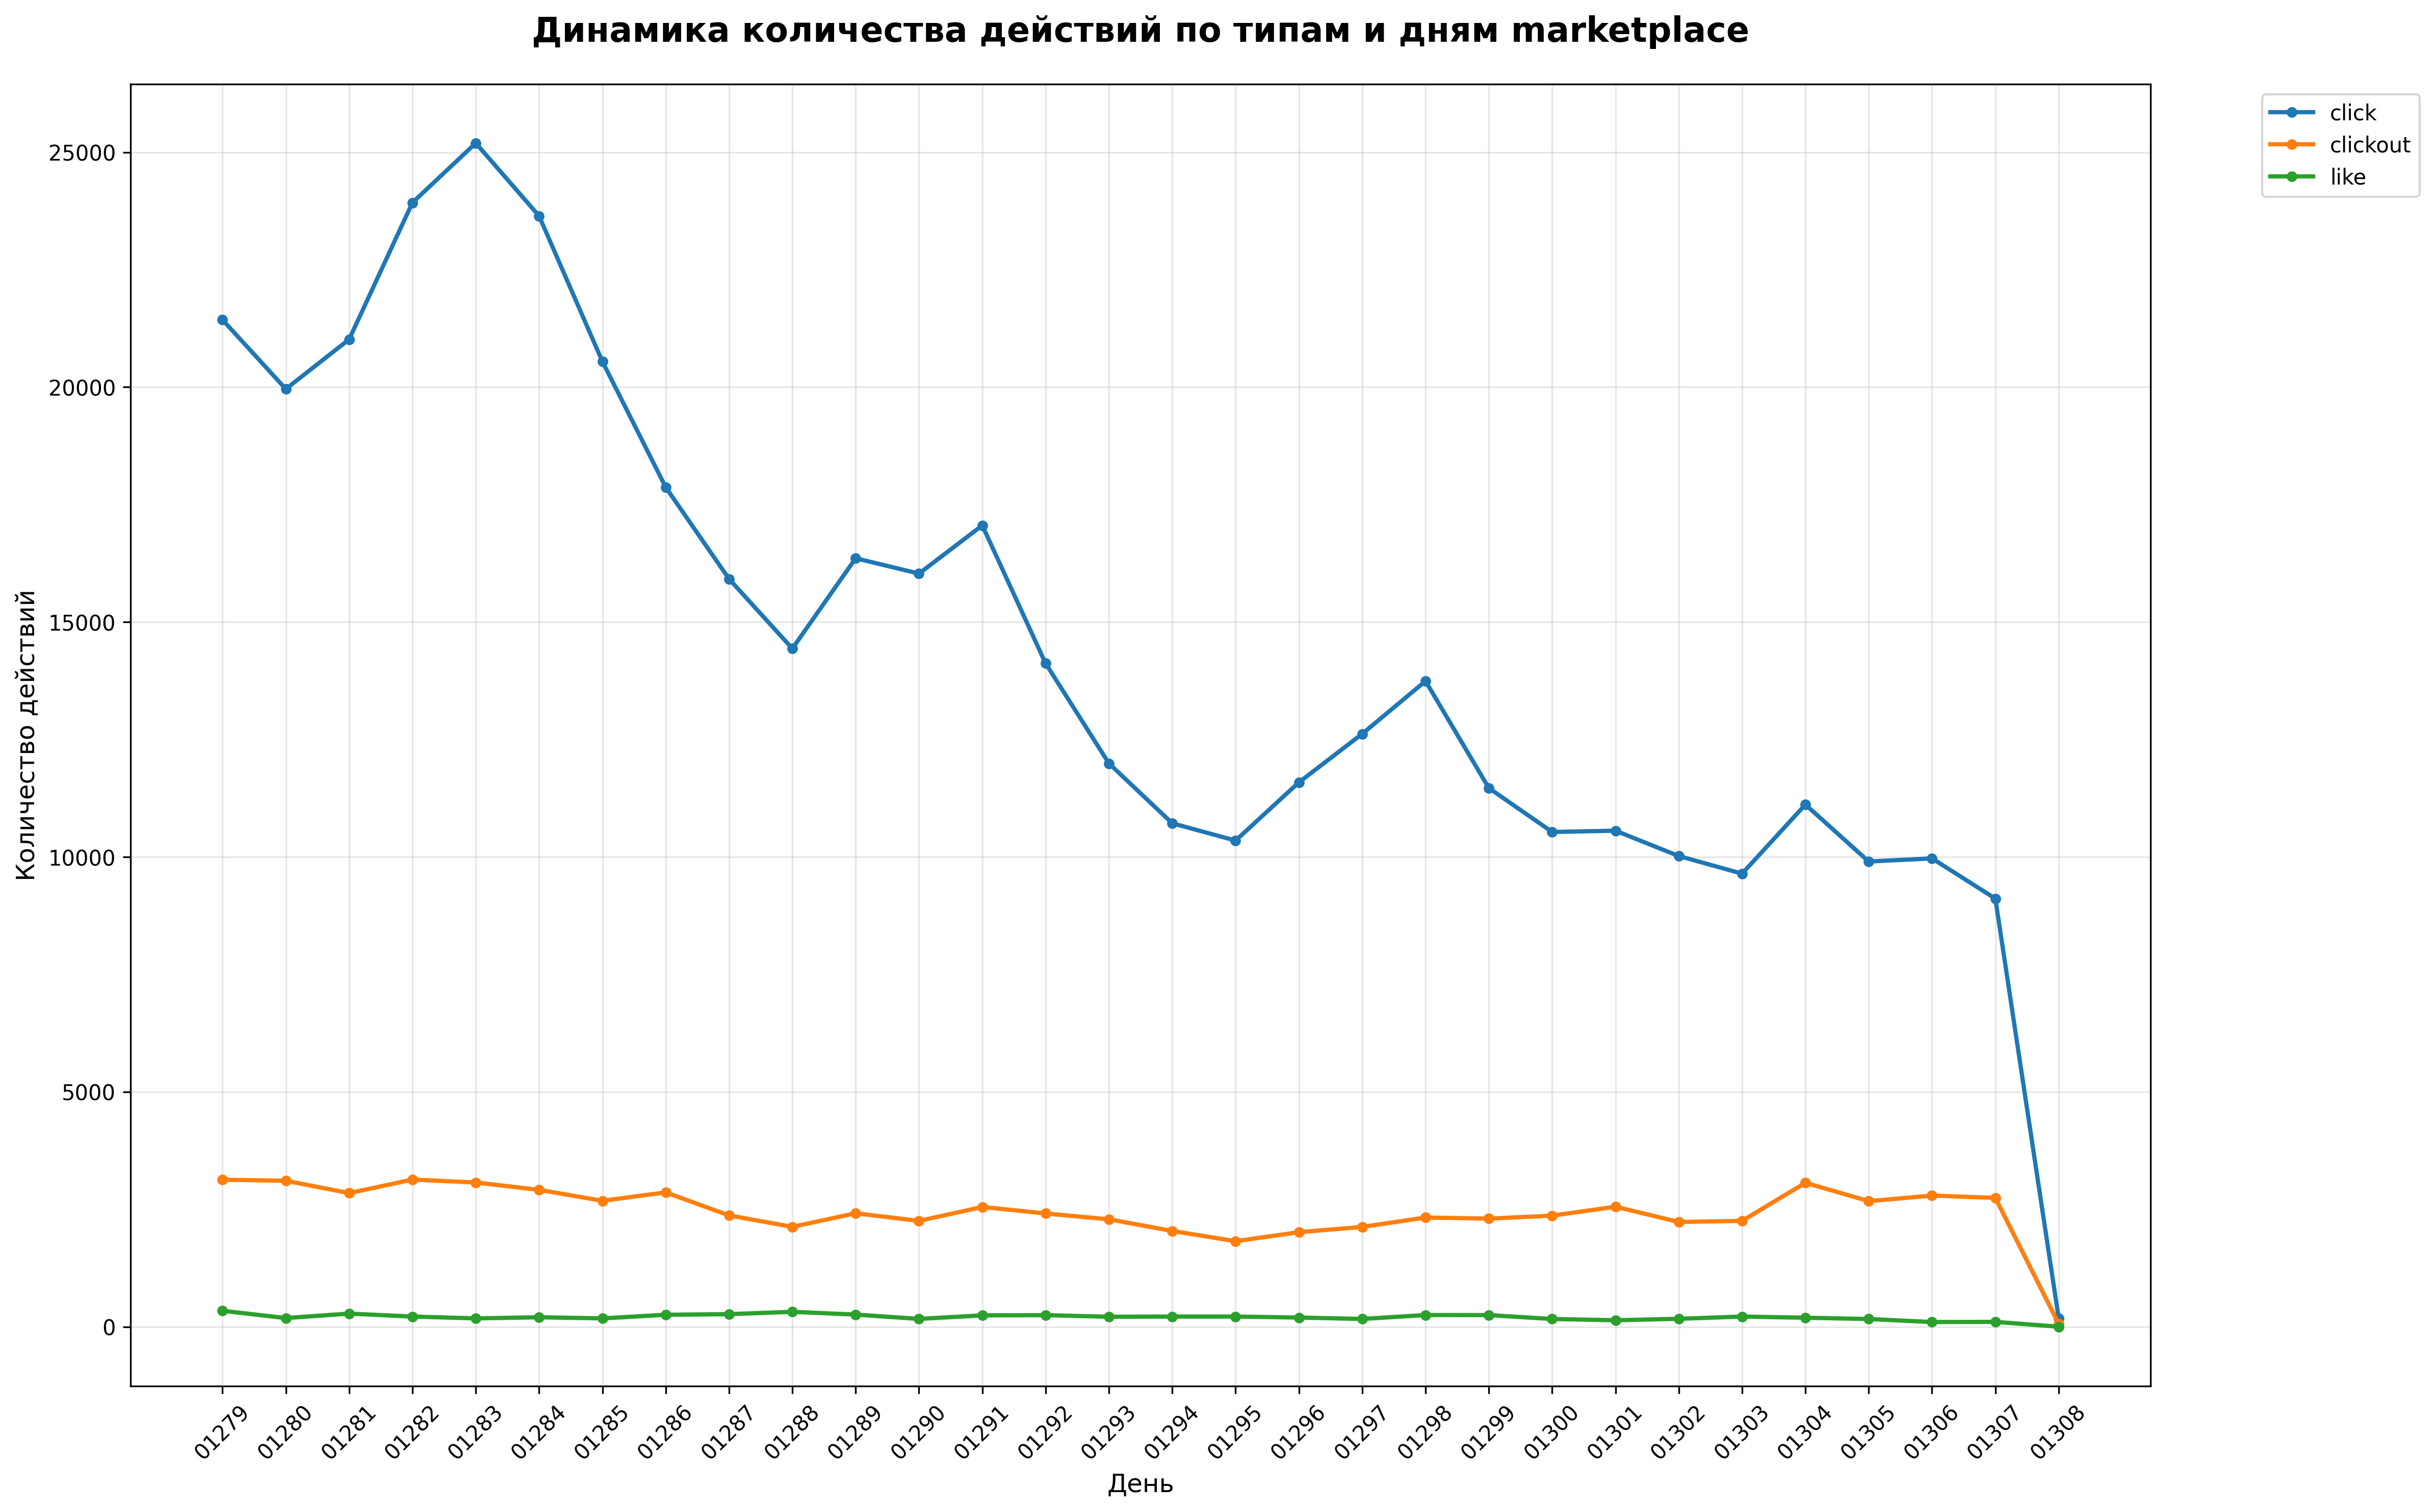

In [1]:
#Теперь маркетплейс, но еще и без кликов
plt.figure(figsize=(16, 10))
market_events_without_view_cl = marker_action_dynamics.iloc[:, 1:3]

for action in market_events_without_view_cl.columns:
    plt.plot(market_events_without_view_cl.index, market_events_without_view_cl[action],
             marker='o', linewidth=2, markersize=4, label=action)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Динамика количества действий по типам и дням marketplace', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День', fontsize=12)
plt.ylabel('Количество действий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

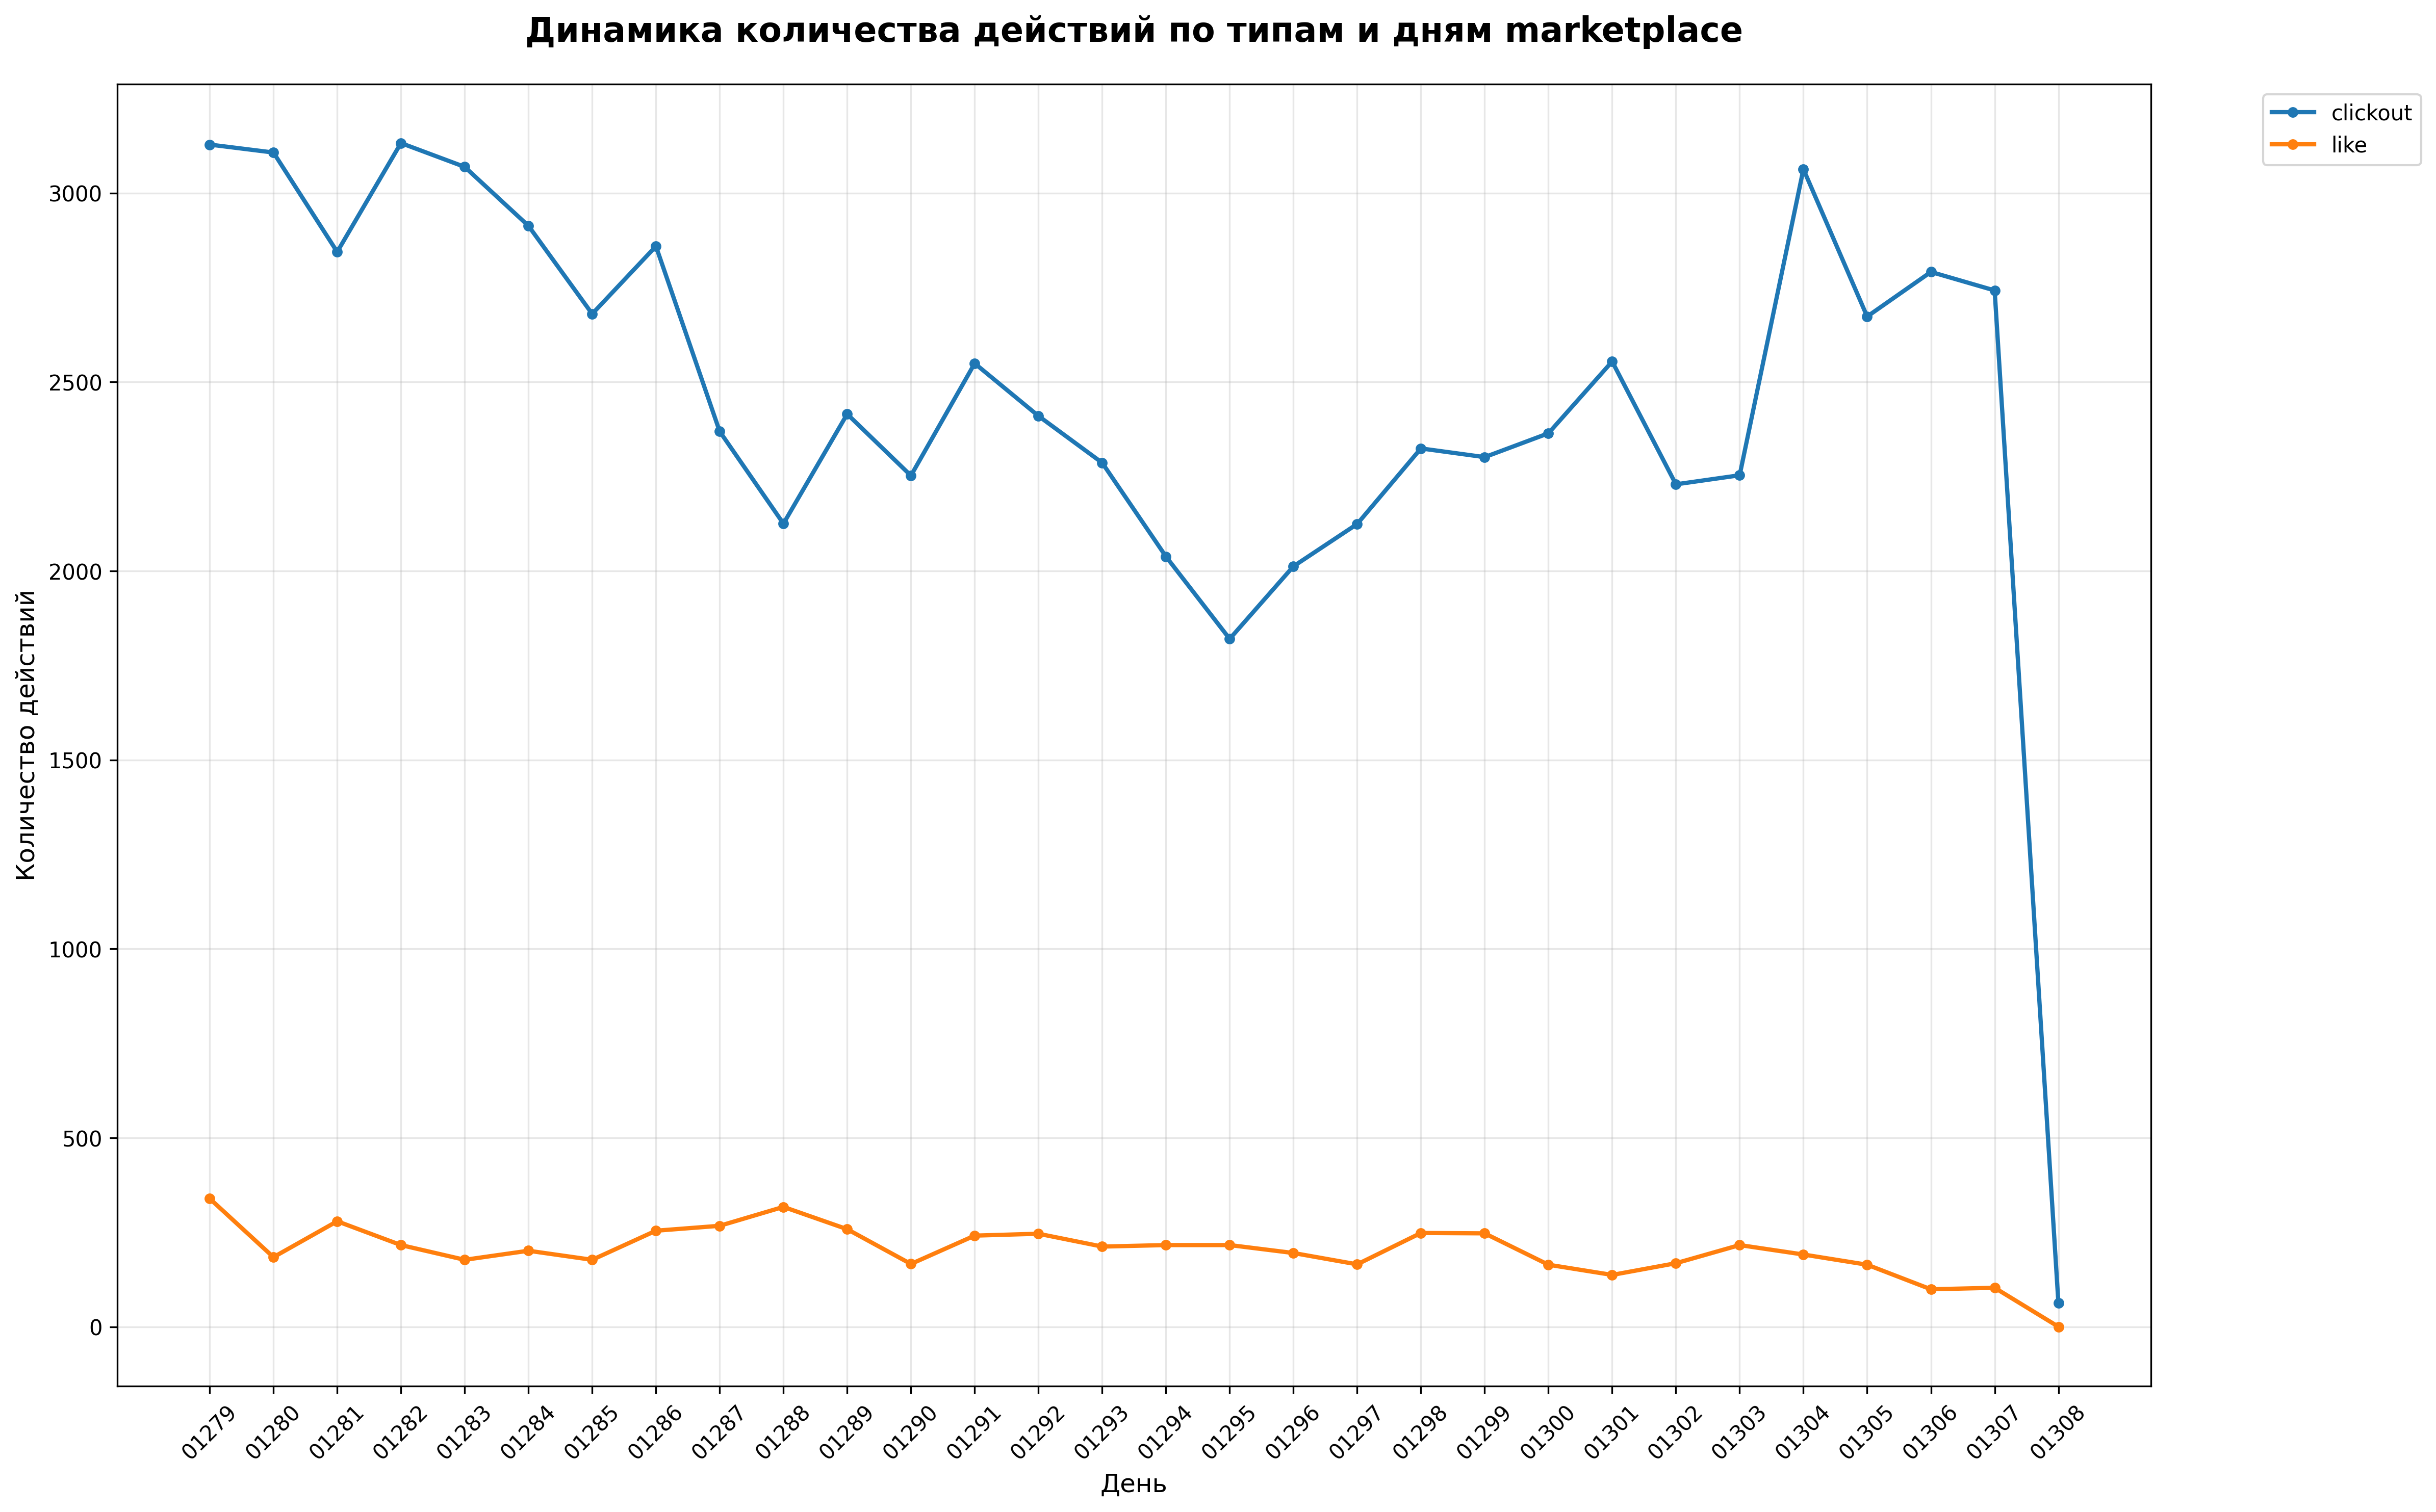

1308 день - это первый день датасета.

Действия в этот день:

view        533107
click          184
clickout        63

In [ ]:
#то же самое для ритейл
retail_action_dynamics = pd.crosstab(retail_events_df['day'], retail_events_df['action_type'])
retail_actions_without_view = retail_action_dynamics.iloc[:, :2]
print(retail_actions_without_view.head())
plt.figure(figsize=(16, 10))

for action in retail_actions_without_view.columns:
    plt.plot(retail_actions_without_view.index, retail_actions_without_view[action],
             marker='o', linewidth=2, markersize=4, label=action)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Динамика количества действий по типам и дням retail', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День', fontsize=12)
plt.ylabel('Количество действий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

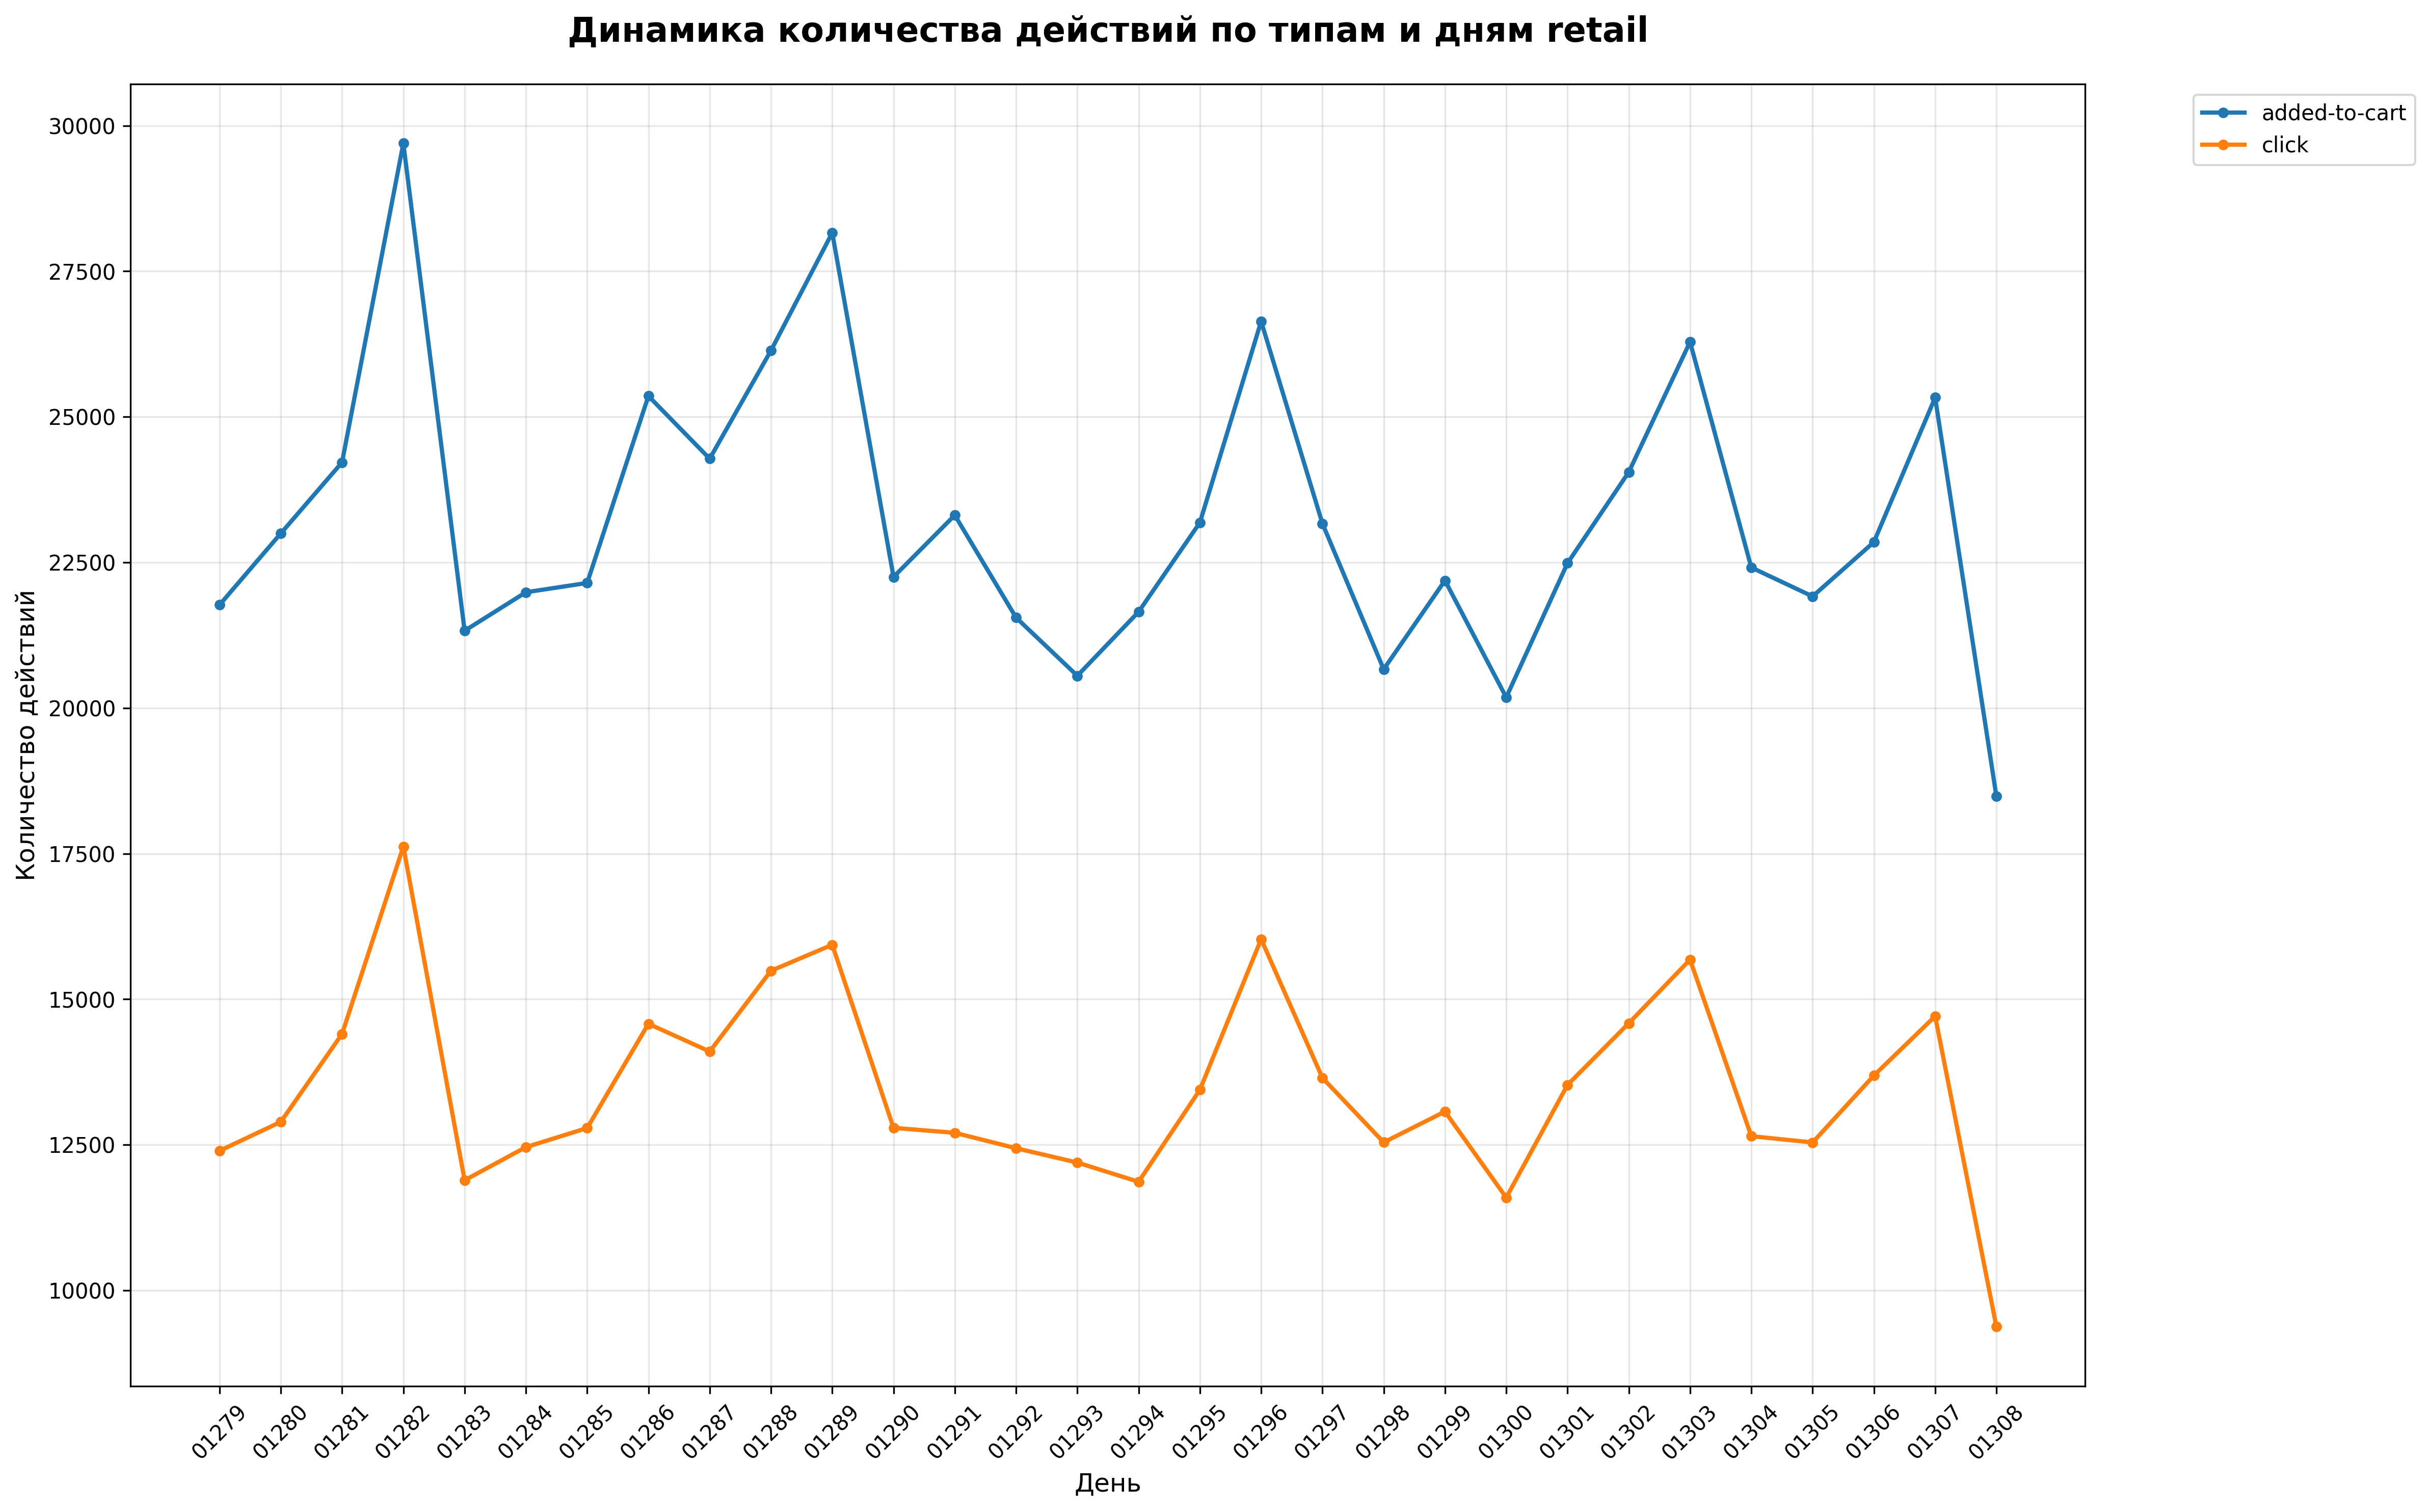

#Рассмотрим количество действий по категориям в маркетплейс и ритейл

In [1]:
#Маркетплейс
items_marketplace = pd.read_parquet('/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/marketplace/items.pq', engine='fastparquet')

#Объединяем события с товарами по item_id
merged_df = marketplace_events_df.merge(
    items_marketplace[['item_id', 'category']],
    on='item_id',
    how='left'
)

actions_by_category = merged_df.groupby('category').size().reset_index(name='actions_count')
actions_by_category = actions_by_category.sort_values('actions_count', ascending=False)
actions_by_category.set_index('actions_count')
print(actions_by_category.head(10))
print(actions_by_category.shape)

#Строим график
plt.figure(figsize=(12, 8))
plt.bar(actions_by_category['category'], actions_by_category['actions_count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Категория')
plt.ylabel('Количество действий')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Действия по категориям Marketplace')
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

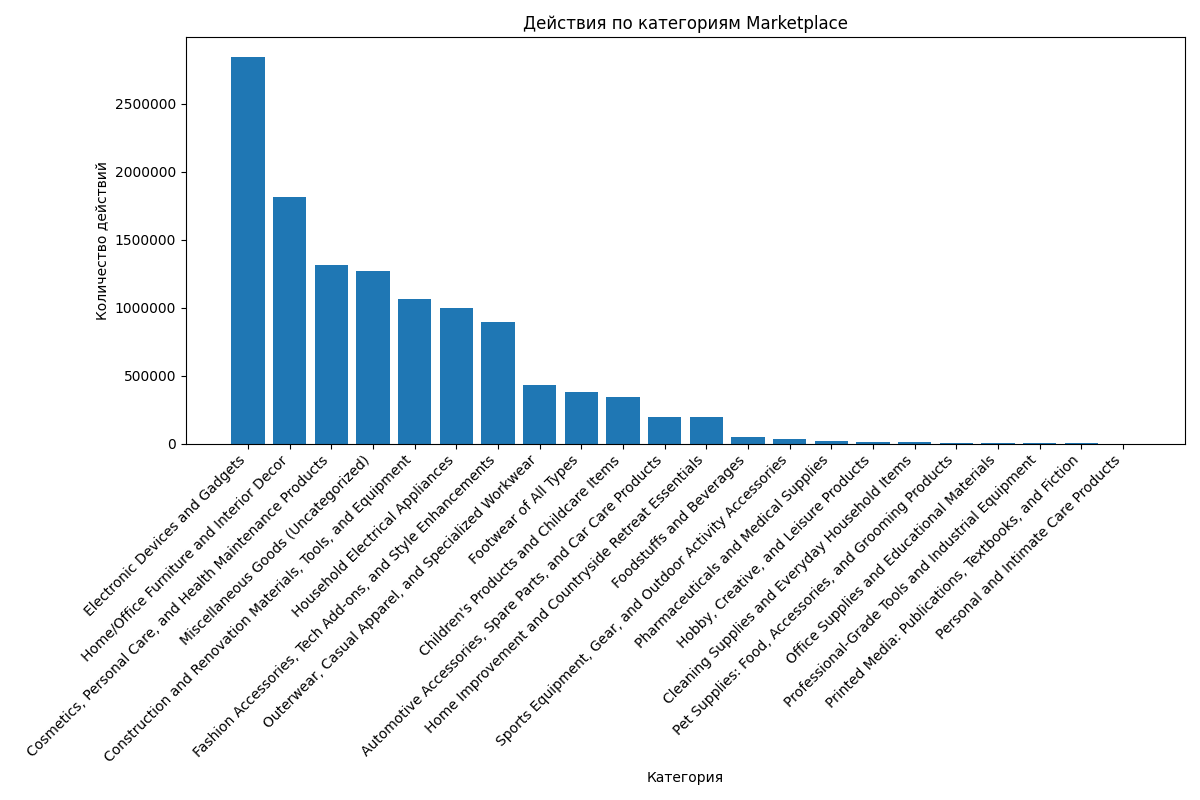

In [ ]:
#проделываю то же самое для папки ритейл
items_retail = pd.read_parquet('/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/retail/items.pq', engine='fastparquet')

merged_retail_df = retail_events_df.merge(
    items_retail[['item_id', 'category']],
    on='item_id',
    how='left'
)

actions_by_category_retail = merged_retail_df.groupby('category').size().reset_index(name='actions_count')
actions_by_category_retail  = actions_by_category_retail.sort_values('actions_count', ascending=False)
actions_by_category_retail .set_index('actions_count')
print(actions_by_category_retail.head(10))
print(actions_by_category_retail.shape)

#Строим график
plt.figure(figsize=(12, 8))
plt.bar(actions_by_category_retail['category'], actions_by_category_retail['actions_count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Категория')
plt.ylabel('Количество действий')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Действия по категориям Retail')
plt.tight_layout()
plt.show()

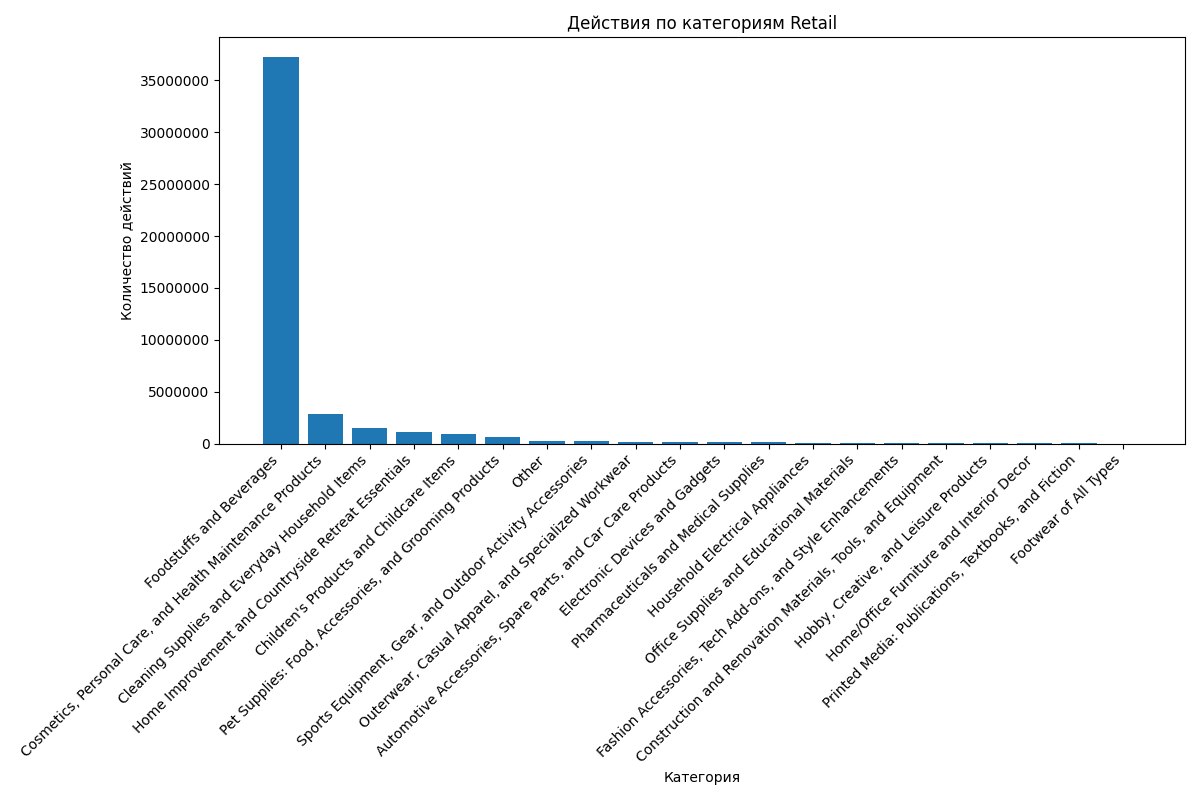

#Теперь построим heatmap для категорий и типов действий, чтоб понять, в каких категориях больше целевых действий и какая разбивка.

In [ ]:
pivot_table = pd.crosstab(
    index = merged_df['category'],
    columns = merged_df['action_type']
)

#Беру топ 20 категорий
top_categories = actions_by_category.head(20)['category'].tolist()
pivot_table_filtered = pivot_table.loc[top_categories]

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table_filtered, fmt='d', cmap='Reds', annot=True, linewidths=.5)
plt.title('Тепловая карта: типы действий по категориям marketplace')
plt.xlabel('Тип действия')
plt.ylabel('Категория товара')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

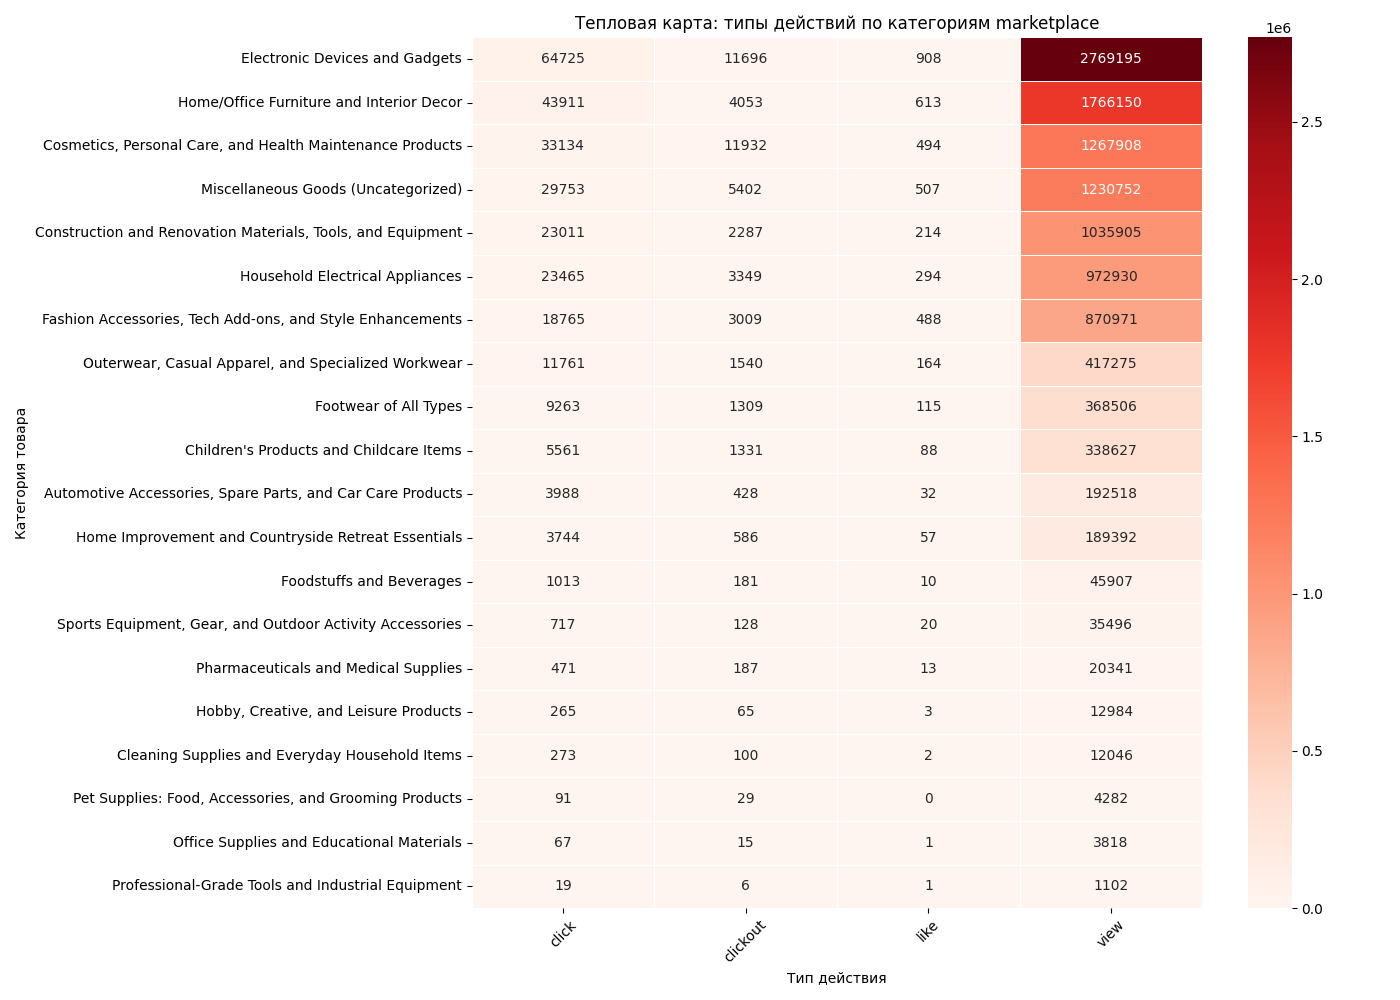

In [ ]:
#построю тепловую карту Действие - категория в retail
pivot_table = pd.crosstab(
    index=merged_retail_df['category'],
    columns=merged_retail_df['action_type']
)

top_categories = actions_by_category_retail.head(20)['category'].tolist()
pivot_table_filtered = pivot_table.loc[top_categories]

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table_filtered, fmt='d', cmap='Reds', annot=True, linewidths=.5)
plt.title('Тепловая карта: типы действий по категориям Retail')
plt.xlabel('Тип действия')
plt.ylabel('Категория товара')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


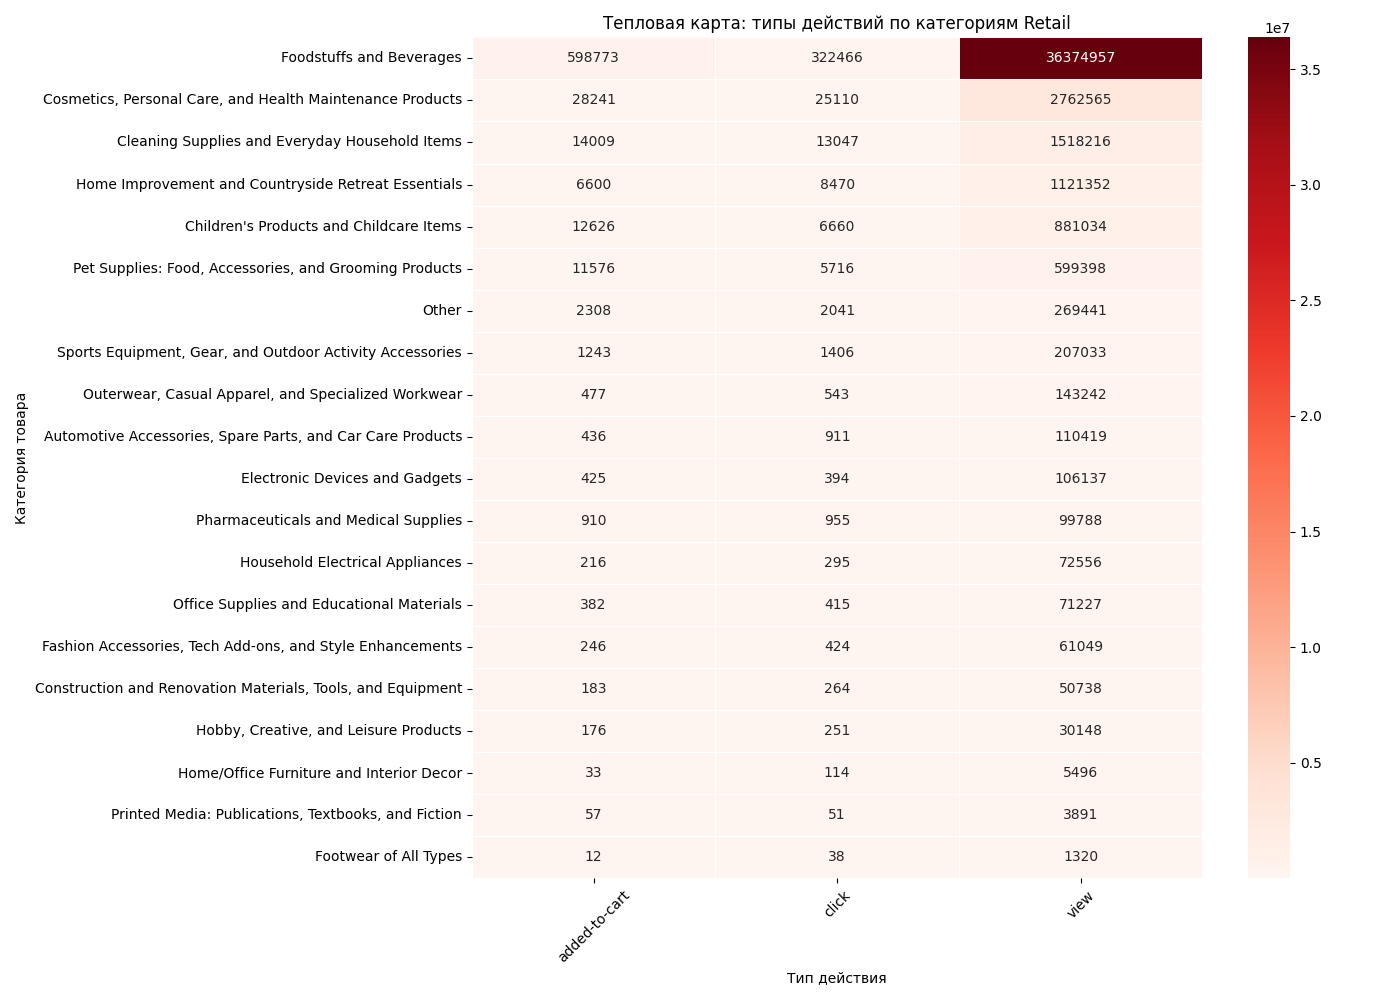